<a href="https://colab.research.google.com/github/Jaspvr/ECE471/blob/main/ECE_471_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 471 Sample Project

This notebook is a template for your final poject.

Your final project report should only include results and figures you can reproduce from your submitted, edited template. This means if we run your submitted collab environment, we should see every result and qualitative figure you submit in your final report.

Your final solution is constrained to the computational limitations of the free google colab environment.

If you choose to use a deep learning method which cannot be trained within the free google colab environemnt, you may load trained models from outside the environement that you trained. Your inference of these models must be able to operate within the free google colab environment. The training code for these models must be a part of your final sumbission, but should be provided outside of the google colab environment. Your results must still be repeatable by simply running the google colab environment, your model weights should automatically be downloaded, simialrly to how the dataset is downloaded below.

If you have any questions on the template reach out to Declan your TA at declanmcintosh@uvic.ca.

We hope that your project submission here will be something you can show off to future employers, as an example of you solving a real-world anomaly detection problem.  



In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a project folder for EfficientAD weights
WEIGHTS_PATH = '/content/drive/MyDrive/ECE471_Project/weights'
os.makedirs(WEIGHTS_PATH, exist_ok=True)

print(f"Weights will be saved to: {WEIGHTS_PATH}")

Mounted at /content/drive
Weights will be saved to: /content/drive/MyDrive/ECE471_Project/weights


In [2]:
# Download the dataset, setup packages
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Downloading...
From: https://drive.google.com/uc?id=1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
To: /content/dataset.zip
100% 2.60M/2.60M [00:00<00:00, 156MB/s]


In [3]:
# Some helper functions for your project
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [4]:
# TODO import any packages you would like to use here
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from fastai.data.external import untar_data, URLs
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.optim as optim

In [5]:
# TODO This class will be the class you will modify for your project.
# The current implementation of this model tries to take the median of all the
# Training images and then measure the L2 distance between this median and any
# test images.
# To be clear this is a BAD method and yours will (hopefully) be better.

'''
EfficientAD information for our reference: (via https://arxiv.org/abs/2303.14535)
- 2 main parts
  - Student-teacher network: The teacher gets patch-level features from the image
    then the student is trained only on normal (non-anomalous) images and attempts
    to immitate the teacher. On a test image, if the student fails to match the
    teacher on a specific region, then this region is identified as an anomaly.

  - Autoencoder: This is used to detect global anomalies. The autoencoder is trained
    to reproduce teacher feature representations of normal images. It has to use
    the whole image rather than a region, so it identifies if something is globally
    wrong. The student network also learns to predict autoencoder output on normal
    images only. At test time, the student and autoencoder will be different if there
    is some global anomaly.

- A patch description network (PDN) is used for the regions. This is a small convolutional
  network. This PDN is also designed in the paper.
- Network only looks at where the student matches the teacher the worst, ensuring that the
  student doesnt become too good at generalizing and correctly predicting anomalies.

- So we get local anomaly map from teacher vs student, global map from autoencoder vs student,
  then we combine them to get the final map from which we generate anomaly scores for each
  pixel.

- Autoencoder is a neural network that takes input and compresses it into its main structures.

'''

class AnomalyDetector:
  def __init__(self,):
    self.model = None
  def create_model(self, dataset : np.ndarray):
    self.model = np.mean(dataset, axis=0)
    print(dataset.shape)
    plt.figure(figsize = (16,5))
    plt.imshow(self.model)
    plt.show()
  def predict(self, test_data : np.ndarray):
    return np.mean(np.square(test_data - self.model), axis=(1,2,3))



In [6]:
# Load the pretrained weights of WideResNet-101 trained on ImageNet
# This will act as the truth from which the teacher network will learn
oracle = models.wide_resnet101_2(weights='IMAGENET1K_V1')
# Set to evaluation mode as we are not training it, just using it.
oracle.eval()

# Freeze all of the oracle's weight values
for param in oracle.parameters():
  param.requires_grad = False

# Switch to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

oracle.to(device)

print(f"WideResNet-101 loaded and frozen on {device}.")

Downloading: "https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet101_2-32ee1156.pth


100%|██████████| 243M/243M [00:02<00:00, 90.5MB/s]


WideResNet-101 loaded and frozen on cuda.


In [7]:
# Get the Imagenette images
# Imagenette is a labelled subset of ImagNet
path = untar_data(URLs.IMAGENETTE)

distillation_data_path = os.path.join(path, 'train')

<div><progress max="1557161267" value="1557168128"></progress> 100.00% [1557168128/1557161267 00:29&lt;00:00]</div>

In [8]:
class OracleWrapper(nn.Module):
  def __init__(self, backbone):
    super(OracleWrapper, self).__init__()
    self.backbone = backbone

    self.layer2 = backbone.layer2
    self.layer3 = backbone.layer3

  def forward(self, x):

    # Initialize layers of WideResNet
    x = self.backbone.conv1(x)
    x = self.backbone.bn1(x)
    x = self.backbone.relu(x)
    x = self.backbone.maxpool(x)
    x = self.backbone.layer1(x)

    # We want to extract intermediate features as done in the EfficientAD paper
    f2 = self.layer2(x)
    f3 = self.layer3(f2)

    # Resize such that both layers are 64x64 so they can be combined
    f2 = F.interpolate(f2, size=(64, 64), mode='bilinear', align_corners=False)
    f3 = F.interpolate(f3, size=(64, 64), mode='bilinear', align_corners=False)
    # Combine the 512 and 1024 channels into one block of size 1536
    combined = torch.cat([f2, f3], dim=1)
    # Project this down to 384 channels as required by EfficientAD
    # We take the first 384 channels as these should have the most information
    projected = combined[:, :384, :, :]

    return projected

oracle_extractor = OracleWrapper(oracle).to(device)




In [22]:
# Get dataset statistics to save and use later

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

distill_dataset = datasets.ImageFolder(root=os.path.join(path, 'train'), transform=transform)
distill_loader = DataLoader(distill_dataset, batch_size=1, shuffle=True)

channel_values = [[] for _ in range(384)]
num_images_to_sample = 500

with torch.no_grad():
  for i, (images, _) in enumerate(distill_loader):

    if i >= num_images_to_sample:
      break

    images = images.to(device)
    features = oracle_extractor(images)

    for c in range(384):

      channel_values[c].append(features[0, c].cpu().numpy().flatten())

    if i % 50 == 0:
      print(f"Processed {i}/{num_images_to_sample} images...")

oracle_mean = torch.zeros(384).to(device)
oracle_variance = torch.zeros(384).to(device)

for c in range(384):
  all_values = np.concatenate(channel_values[c])
  oracle_mean[c] = torch.tensor(np.mean(all_values))
  oracle_variance[c] = torch.tensor(np.std(all_values))
  print(f"saved mean and variance {c} / 384")

print(f"Mean shape: {oracle_mean.shape}") # Should be [384]
print(f"Variance shape: {oracle_variance.shape}") # Should be [384]
print(f"First 5 means: {oracle_mean[:5]}")

# Save to Drive
torch.save({'mu': oracle_mean, 'sigma': oracle_variance},
           os.path.join(WEIGHTS_PATH, 'oracle_stats.pth'))

Processed 0/500 images...
Processed 50/500 images...
Processed 100/500 images...
Processed 150/500 images...
Processed 200/500 images...
Processed 250/500 images...
Processed 300/500 images...
Processed 350/500 images...
Processed 400/500 images...
Processed 450/500 images...
saved mean and variance 0 / 384
saved mean and variance 1 / 384
saved mean and variance 2 / 384
saved mean and variance 3 / 384
saved mean and variance 4 / 384
saved mean and variance 5 / 384
saved mean and variance 6 / 384
saved mean and variance 7 / 384
saved mean and variance 8 / 384
saved mean and variance 9 / 384
saved mean and variance 10 / 384
saved mean and variance 11 / 384
saved mean and variance 12 / 384
saved mean and variance 13 / 384
saved mean and variance 14 / 384
saved mean and variance 15 / 384
saved mean and variance 16 / 384
saved mean and variance 17 / 384
saved mean and variance 18 / 384
saved mean and variance 19 / 384
saved mean and variance 20 / 384
saved mean and variance 21 / 384
saved m

In [18]:
class AutoEncoder(nn.Module):
  def __init__(self,):
    super().__init__()

    # Encoder Layers as class attributes. Conv2d docs:
    # https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
    # Input channels is what the layer receives, and output channels is
    # specified in table 8 of the paper.
    # Kernel size, stride, and padding all taken directly from table 8
    self.EncConv1 = nn.Conv2d(in_channels=3, out_channels=32,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv2 = nn.Conv2d(in_channels=32, out_channels=32,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv3 = nn.Conv2d(in_channels=32, out_channels=64,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv4 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv5 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv6 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(8, 8), stride=(1, 1), padding=0)

    # Decoder layers (more Conv2D)
    self.DecConv1 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv2 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv3 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv4 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv5 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv6 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv7 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(3, 3), stride=(1, 1), padding=1)
    self.DecConv8 = nn.Conv2d(in_channels=64, out_channels=384,
                              kernel_size=(3, 3), stride=(1, 1), padding=1)

    # Bilinear Layers: https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html
    self.Bilinear1 = nn.Upsample(size=(3, 3), mode="bilinear")
    self.Bilinear2 = nn.Upsample(size=(8, 8), mode="bilinear")
    self.Bilinear3 = nn.Upsample(size=(15, 15), mode="bilinear")
    self.Bilinear4 = nn.Upsample(size=(32, 32), mode="bilinear")
    self.Bilinear5 = nn.Upsample(size=(63, 63), mode="bilinear")
    self.Bilinear6 = nn.Upsample(size=(127, 127), mode="bilinear")
    self.Bilinear7 = nn.Upsample(size=(64, 64), mode="bilinear")

    # Dropout Layers: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html
    self.Dropout1To6 = nn.Dropout(p=0.2) # All dropout layers have the same p value

    # Relu activation function (for convenience)
    self.relu = nn.ReLU()

  def forward(self, x):
    # Compute a forward pass. Here we just combine the layers in the order of table 8 in the EfficientAD paper
    out = self.relu(self.EncConv1(x))
    out = self.relu(self.EncConv2(out))
    out = self.relu(self.EncConv3(out))
    out = self.relu(self.EncConv4(out))
    out = self.relu(self.EncConv5(out))
    out = self.EncConv6(out)

    out = self.Bilinear1(out)

    out = self.relu(self.DecConv1(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear2(out)

    out = self.relu(self.DecConv2(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear3(out)

    out = self.relu(self.DecConv3(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear4(out)

    out = self.relu(self.DecConv4(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear5(out)

    out = self.relu(self.DecConv5(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear6(out)

    out = self.relu(self.DecConv6(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear7(out)

    out = self.relu(self.DecConv7(out))
    out = self.DecConv8(out)

    return out


'''
AutoEncoder information for EfficientAD: (via https://arxiv.org/abs/2303.14535)
- Input to the autoencoder is entire images, and a single compression is output
- Via the paper, "We use a standard convolutional autoencoder comprising strided convolutions in the encoder and bilinear upsampling in the decoder. We provide the detailed hyperparameters of its layers
in in Appendix A."
- In Appendix A:
  - Sizes of input and output of the autoencoder: input - R(3, 256, 256) and output - R(384, 64, 64).
    So the input is a RGB of size 256x256 and the output is a 384 feature descriptor of each 4x4 patch
    in the image.
  - Pytorch is used for the convolutional layers
  - The architecture of the autoencoder is given in Table 8. The info used from there is below (layers in order):
    - 6 EncConv layers (standard 2D Convolution Layers) with differing strides


  - Then the tabel described the decoder part which we will add separately.


- Actual code implementation:
  - torch.nn class is the standard for creating custom neural network classes
  - We use nn.Module as the base class then add our custom layers and such on top of it
  - super().__init__() is used to initalize our class when we are building a
    custom class in this way.
'''

'\nAutoEncoder information for EfficientAD: (via https://arxiv.org/abs/2303.14535)\n- Input to the autoencoder is entire images, and a single compression is output\n- Via the paper, "We use a standard convolutional autoencoder comprising strided convolutions in the encoder and bilinear upsampling in the decoder. We provide the detailed hyperparameters of its layers\nin in Appendix A."\n- In Appendix A:\n  - Sizes of input and output of the autoencoder: input - R(3, 256, 256) and output - R(384, 64, 64).\n    So the input is a RGB of size 256x256 and the output is a 384 feature descriptor of each 4x4 patch\n    in the image.\n  - Pytorch is used for the convolutional layers\n  - The architecture of the autoencoder is given in Table 8. The info used from there is below (layers in order):\n    - 6 EncConv layers (standard 2D Convolution Layers) with differing strides\n\n\n  - Then the tabel described the decoder part which we will add separately.\n\n\n- Actual code implementation:\n  - to

In [11]:
class PDN(nn.Module):
  def __init__(self, out_channels=384, padding=True):
    super(PDN, self).__init__()

    p = 3 if padding else 0

    self.conv1 = nn.Conv2d(3, 128, kernel_size=4, stride=1, padding=p);
    self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1);
    self.conv2 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=p);
    self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1);
    self.conv3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1);
    self.conv4 = nn.Conv2d(256, out_channels, kernel_size=4, stride=1, padding=0);

    self.relu = nn.ReLU(inplace=True);

    # Compute the forward pass
  def forward(self, x):
    x = self.relu(self.conv1(x))
    x = self.avgpool1(x)
    x = self.relu(self.conv2(x))
    x = self.avgpool2(x)
    x = self.relu(self.conv3(x))
    x = self.conv4(x)
    return x



In [13]:
# We use this helper to calculate the mean squared error
# This method is described in Section 3.1 and Algorithm 3 of the EfficientAD paper
def distillation_loss(teacher_output, oracle_output, mu, sigma):

  # Reshape mu and sigma
  mu = mu.view(1, -1, 1, 1)
  sigma = sigma.view(1, -1, 1, 1)
  # Normalize the oracle output
  normalized_oracle = (oracle_output - mu) / sigma
  # Compute the loss
  loss = torch.mean((teacher_output - normalized_oracle) ** 2)

  return loss

In [13]:
def train_teacher(teacher, oracle, dataloader, mu, sigma, iterations=10000):
  teacher.train()
  oracle.eval()

  optimizer = optim.Adam(teacher.parameters(), lr=2e-4, weight_decay=1e-5)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000)

  data_iter = iter(dataloader)

  for i in range(iterations):

    try:
      images, _ = next(data_iter)
    except StopIteration:
      data_iter = iter(dataloader)
      images, _ = next(data_iter)

    images = images.to(device)

    optimizer.zero_grad()

    # Get the oracle features
    with torch.no_grad():
      y_oracle = oracle(images)

    # Get the teacher features
    y_teacher = teacher(images)

    loss = distillation_loss(y_teacher, y_oracle, mu, sigma)

    # Backward Pass
    loss.backward()
    optimizer.step()
    scheduler.step()

    if i % 100 == 0:
      print(f"Iteration {i}/{iterations}  Loss: {loss.item():.6f}")



In [19]:
teacher = PDN().to(device)

In [14]:

distill_loader = DataLoader(distill_dataset, batch_size=16, shuffle=True, drop_last=True)

train_teacher(
    teacher=teacher,
    oracle=oracle_extractor,
    dataloader=distill_loader,
    mu=oracle_mean,
    sigma=oracle_variance,
    )

Iteration 0/10000  Loss: 0.907597
Iteration 100/10000  Loss: 0.768983
Iteration 200/10000  Loss: 0.767480
Iteration 300/10000  Loss: 0.697023
Iteration 400/10000  Loss: 0.679018
Iteration 500/10000  Loss: 0.622105
Iteration 600/10000  Loss: 0.578754
Iteration 700/10000  Loss: 0.555488
Iteration 800/10000  Loss: 0.584840
Iteration 900/10000  Loss: 0.558735
Iteration 1000/10000  Loss: 0.536111
Iteration 1100/10000  Loss: 0.514387
Iteration 1200/10000  Loss: 0.523931
Iteration 1300/10000  Loss: 0.503403
Iteration 1400/10000  Loss: 0.483656
Iteration 1500/10000  Loss: 0.502923
Iteration 1600/10000  Loss: 0.457890
Iteration 1700/10000  Loss: 0.536984
Iteration 1800/10000  Loss: 0.513865
Iteration 1900/10000  Loss: 0.479968
Iteration 2000/10000  Loss: 0.477162
Iteration 2100/10000  Loss: 0.472289
Iteration 2200/10000  Loss: 0.444534
Iteration 2300/10000  Loss: 0.486389
Iteration 2400/10000  Loss: 0.485694
Iteration 2500/10000  Loss: 0.444726
Iteration 2600/10000  Loss: 0.469679
Iteration 270

KeyboardInterrupt: 

In [21]:
PROJECT_WEIGHTS_PATH = '/content/drive/MyDrive/ECE471_Project/weights'
file_name = 'teacher_final_optimized.pth'
full_save_path = os.path.join(PROJECT_WEIGHTS_PATH, file_name)

# Save weights to teacher, set to evaluation mode and disable gradients (freeze teacher)
torch.save(teacher.state_dict(), full_save_path)
teacher.load_state_dict(torch.load(full_save_path))
teacher.eval()
for param in teacher.parameters():
  param.requires_grad = False

In [ ]:
# Possibly add student and autoencoder definitions here to get them without running training

In [23]:
# Get data
pasta_training_data, pasta_testing_data, pasta_testing_labels = load_dataset("pasta")
screws_training_data, screws_testing_data, screws_testing_labels = load_dataset("screws")

In [ ]:
# Follow Algorithm 1 in the paper to train the autoencoder and student
# As in the paper, need pretrained teacher (we have), sequence of training/validation images (given)

def train_autoencoder():
  # Output is 768x64x64 as per paper
  student = PDN(out_channels=768).to(device)
  autoencoder = AutoEncoder().to(device)

  # Algorithm 1 computes normalization parameters mu and sigma. We have these precomputed
  oracle_stats_path = os.path.join(WEIGHTS_PATH, 'oracle_stats.pth')
  oracle_stats = torch.load(oracle_stats_path)
  mu = oracle_stats['mu'].to(device)
  sigma = oracle_stats['sigma'].to(device)

  # Now we initialize Adam for parameters of student and autoencoder (learning rate and weight decay from algorithm 1)
  student_optimizer = optim.Adam(student.parameters(), lr=1e-4, weight_decay=1e-5)
  autoencoder_optimizer = optim.Adam(autoencoder.parameters(), lr=1e-4, weight_decay=1e-5)

  # Main training loop
  for i in range(1, 70001):
    # Choose 'random' training image, do fwd pass with teacher, do fwd pass with student,
    index = np.random.ranint(len(pasta_training_data))
    random_image = pasta_training_data[index]
    random_image = torch.tensor(random_image).to(device)

    teacher_output = teacher(random_image)
    student_output = student(random_image)

    # Get the normalized teacher output per channel. Have to resize the mu and sigma to match dimensions of teacher output
    mu = mu.view(1, 384, 1, 1)
    sigma = sigma.view(1, 384, 1, 1)
    normalized_teacher_output = (teacher_output - mu) / sigma

    # Now compute square difference between normalized teacher output and the first 384 entries of the student output
    student_output_384 = student_output[:, :384, :, :]
    DST_cwh = (normalized_teacher_output - student_output_384)**2


(18, 224, 224, 3)


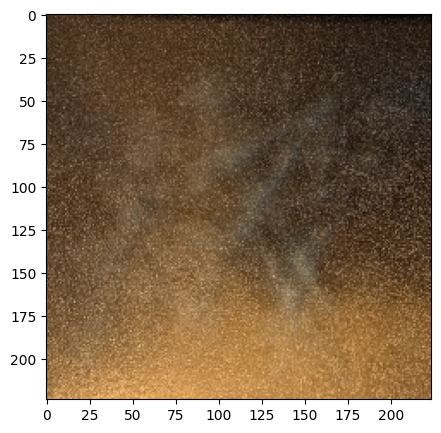

[0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0.01266274 0.01262501 0.01128812 0.01189333 0.01267228 0.01220351
 0.00899846 0.02623149 0.0070275  0.01327617 0.01168453 0.01184507
 0.01503672 0.01297135 0.01109155]
AUROC Score: 0.48
(17, 224, 224, 3)


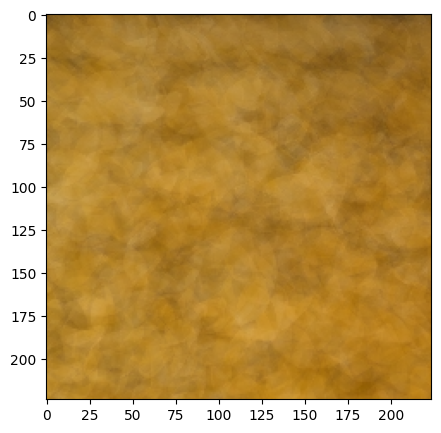

[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0.02781279 0.02871893 0.02962093 0.03351079 0.02817912 0.02717947
 0.02904834 0.03291886 0.02258807 0.03534515 0.02747697 0.02566343
 0.03082341 0.04285557 0.02779141 0.02496582]
AUROC Score: 0.4666666666666666


In [17]:
# TODO use your class above as well as helper functions to generate your
# predictions on the datasets and evaluate the results.
def do_analysis(ad, class_name):
  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)
  ad.create_model(training_images)
  predictions = ad.predict(testing_images)
  basic_evaluation(predictions, testing_labels)

do_analysis(AnomalyDetector(), 'screws')
do_analysis(AnomalyDetector(), 'pasta')
